# pandas テスト

### データフレームにデータを読み込む

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px

df = px.data.gapminder()
print(df)

          country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0     Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1     Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2     Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3     Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4     Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   
...           ...       ...   ...      ...       ...         ...       ...   
1699     Zimbabwe    Africa  1987   62.351   9216418  706.157306       ZWE   
1700     Zimbabwe    Africa  1992   60.377  10704340  693.420786       ZWE   
1701     Zimbabwe    Africa  1997   46.809  11404948  792.449960       ZWE   
1702     Zimbabwe    Africa  2002   39.989  11926563  672.038623       ZWE   
1703     Zimbabwe    Africa  2007   43.487  12311143  469.709298       ZWE   

      iso_num  
0           4  
1           4  
2           4  

### 日本の情報のみ抽出。

In [4]:
df[df["country"]=="Japan"]

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
792,Japan,Asia,1952,63.030,86459025,3216.956347,JPN,392
793,Japan,Asia,1957,65.500,91563009,4317.694365,JPN,392
794,Japan,Asia,1962,68.730,95831757,6576.649461,JPN,392
795,Japan,Asia,1967,71.430,100825279,9847.788607,JPN,392
796,Japan,Asia,1972,73.420,107188273,14778.786360,JPN,392
797,Japan,Asia,1977,75.380,113872473,16610.377010,JPN,392
798,Japan,Asia,1982,77.110,118454974,19384.105710,JPN,392
799,Japan,Asia,1987,78.670,122091325,22375.941890,JPN,392
800,Japan,Asia,1992,79.360,124329269,26824.895110,JPN,392
801,Japan,Asia,1997,80.690,125956499,28816.584990,JPN,392


### 日本における、年ごとの人口を抽出

In [5]:
df[df["country"]=="Japan"][["year","pop"]]

,year,pop
792,1952,86459025
793,1957,91563009
794,1962,95831757
795,1967,100825279
796,1972,107188273
797,1977,113872473
798,1982,118454974
799,1987,122091325
800,1992,124329269
801,1997,125956499


### 日本またはイタリアの情報を抽出せよ。

In [6]:
df[df['country'].isin(['Japan', 'Italy'])]

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
768,Italy,Europe,1952,65.940,47666000,4931.404155,ITA,380
769,Italy,Europe,1957,67.810,49182000,6248.656232,ITA,380
770,Italy,Europe,1962,69.240,50843200,8243.582340,ITA,380
771,Italy,Europe,1967,71.060,52667100,10022.401310,ITA,380
772,Italy,Europe,1972,72.190,54365564,12269.273780,ITA,380
773,Italy,Europe,1977,73.480,56059245,14255.984750,ITA,380
774,Italy,Europe,1982,74.980,56535636,16537.483500,ITA,380
775,Italy,Europe,1987,76.420,56729703,19207.234820,ITA,380
776,Italy,Europe,1992,77.440,56840847,22013.644860,ITA,380
777,Italy,Europe,1997,78.820,57479469,24675.024460,ITA,380


### オセアニアの国の 2007 年のデータを抽出。

In [7]:
df[df["continent"].eq("Oceania") & df["year"].eq(2007)]

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
71,Australia,Oceania,2007,81.235,20434176,34435.36744,AUS,36
1103,New Zealand,Oceania,2007,80.204,4115771,25185.00911,NZL,554


In [9]:
df.query("continent=='Oceania' and year==2007")

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
71,Australia,Oceania,2007,81.235,20434176,34435.36744,AUS,36
1103,New Zealand,Oceania,2007,80.204,4115771,25185.00911,NZL,554


### 2007年の全世界データにおける、平均寿命のヒストグラムを作成

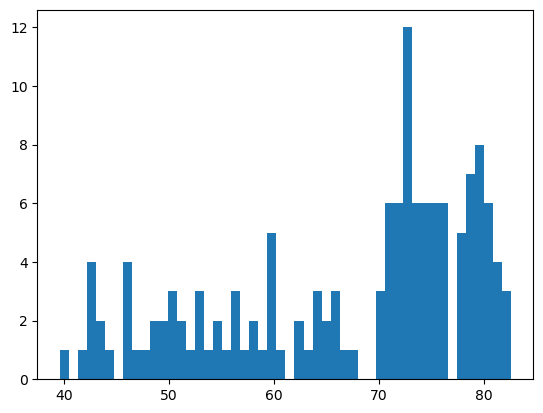

In [10]:
plt.hist(df[df["year"].eq(2007)]["lifeExp"],bins=50)
plt.show()

### 2007年の全世界データにおける、平均寿命が80以上の国名と平均寿命をデータフレームで出力。

In [12]:
df.query("year==2007 and lifeExp > 80")[["country","lifeExp"]]

,country,lifeExp
71,Australia,81.235
251,Canada,80.653
539,France,80.657
671,"Hong Kong, China",82.208
695,Iceland,81.757
767,Israel,80.745
779,Italy,80.546
803,Japan,82.603
1103,New Zealand,80.204
1151,Norway,80.196


### 2007年の全世界データにおける、平均寿命が80以上の件数

In [14]:
(df["year"].eq(2007) & df["lifeExp"].gt(80)).sum()

np.int64(13)